# Variance complète LSTM vs Transformer (FD001 et FD002) + comparaison statistique

**Pourquoi ce notebook** : `06_lstm_seed_variance.ipynb` établit la variance du LSTM sur
FD001 (5 graines), mais les comparaisons LSTM vs Transformer (`13_transformer_fd001.ipynb`,
`14_transformer_fd002.ipynb`) et FD001 vs FD002 (`12_fd001_vs_fd002_comparison.ipynb`)
reposaient chacune sur **une seule graine par modèle**. Une relecture externe du projet a
souligné, à juste titre, que conclure « le LSTM devance légèrement le Transformer sur FD002 »
(15.07 vs 15.63, écart 0.56) sans connaître la variance du Transformer n'est pas défendable :
avec un écart-type inter-graines de l'ordre de 0.42 (LSTM, FD001), un écart de 0.56 est de
l'ordre d'une seule fois cet écart-type — pas assez pour trancher sans test statistique.

Ce notebook complète donc la variance manquante (5 graines, 0 à 4, comme dans
`06_lstm_seed_variance.ipynb`) :
- **LSTM sur FD002** (régime-aware) — manquant jusqu'ici.
- **Transformer sur FD001** — manquant jusqu'ici.
- **Transformer sur FD002** (régime-aware) — manquant jusqu'ici.

puis compare statistiquement LSTM vs Transformer sur chaque volet (test t de Welch, adapté à
des échantillons de petite taille et de variances potentiellement différentes), pour remplacer
les comparaisons qualitatives non étayées par une conclusion défendable.

Le split, les capteurs et les statistiques de normalisation restent strictement identiques aux
notebooks précédents (seed=42 pour le split, seeds 0-4 pour les graines de modèle) — seule la
graine du modèle varie, exactement comme dans `06_lstm_seed_variance.ipynb`.

In [1]:
import sys
sys.path.append("..")

import matplotlib.pyplot as plt
import pandas as pd
import torch
from scipy import stats

from src.metrics import asymmetric_score, rmse
from src.preprocessing import (
    add_piecewise_rul,
    assign_regimes,
    compute_norm_stats,
    compute_norm_stats_by_regime,
    fit_regime_clusters,
    make_windows,
    normalize,
    normalize_by_regime,
    select_features,
    select_features_by_regime,
    split_by_unit,
)
from src.torch_model import RULRegressor, TransformerRULRegressor, set_seed, train_model

SPLIT_SEED = 42
MODEL_SEEDS = [0, 1, 2, 3, 4]
WINDOW_SIZE = 30
RUL_CAP = 125

DATA_DIR = "../DATA/CMaps"
INDEX_NAMES = ["unit_number", "time_cycles"]
SETTING_NAMES = ["setting_1", "setting_2", "setting_3"]
SENSOR_NAMES = [f"sensor_{i}" for i in range(1, 22)]
COL_NAMES = INDEX_NAMES + SETTING_NAMES + SENSOR_NAMES


def load_raw(subset):
    raw = pd.read_csv(f"{DATA_DIR}/train_{subset}.txt", sep=r"\s+", header=None)
    raw = raw.iloc[:, : len(COL_NAMES)]
    raw.columns = COL_NAMES
    return raw


def prepare_fd001():
    """Pipeline FD001 identique à 05_lstm_fd001.ipynb / 13_transformer_fd001.ipynb."""
    raw = load_raw("FD001")
    train_raw, val_raw = split_by_unit(raw, val_fraction=0.2, seed=SPLIT_SEED)
    selected_sensors = select_features(train_raw, SENSOR_NAMES, std_threshold=1e-2)
    norm_stats = compute_norm_stats(train_raw, selected_sensors)

    train_norm = normalize(train_raw, selected_sensors, norm_stats)
    val_norm = normalize(val_raw, selected_sensors, norm_stats)
    train_rul = add_piecewise_rul(train_norm, cap=RUL_CAP)
    val_rul = add_piecewise_rul(val_norm, cap=RUL_CAP)

    X_train, y_train, _ = make_windows(train_rul, selected_sensors, window_size=WINDOW_SIZE, target_col="RUL")
    X_val, y_val, _ = make_windows(val_rul, selected_sensors, window_size=WINDOW_SIZE, target_col="RUL")
    return X_train, y_train, X_val, y_val, len(selected_sensors)


def prepare_fd002():
    """Pipeline FD002 régime-aware identique à 11_fd002_ablation_regime.ipynb (variante B)
    / 14_transformer_fd002.ipynb."""
    raw = load_raw("FD002")
    train_raw, val_raw = split_by_unit(raw, val_fraction=0.2, seed=SPLIT_SEED)

    regime_model = fit_regime_clusters(train_raw, SETTING_NAMES, n_regimes=6, seed=SPLIT_SEED)
    train_regimes = assign_regimes(train_raw, SETTING_NAMES, regime_model)
    val_regimes = assign_regimes(val_raw, SETTING_NAMES, regime_model)

    selected_sensors = select_features_by_regime(train_raw, SENSOR_NAMES, train_regimes, std_threshold=1e-2)
    regime_stats = compute_norm_stats_by_regime(train_raw, selected_sensors, train_regimes)
    train_norm = normalize_by_regime(train_raw, selected_sensors, train_regimes, regime_stats)
    val_norm = normalize_by_regime(val_raw, selected_sensors, val_regimes, regime_stats)

    train_rul = add_piecewise_rul(train_norm, cap=RUL_CAP)
    val_rul = add_piecewise_rul(val_norm, cap=RUL_CAP)

    X_train, y_train, _ = make_windows(train_rul, selected_sensors, window_size=WINDOW_SIZE, target_col="RUL")
    X_val, y_val, _ = make_windows(val_rul, selected_sensors, window_size=WINDOW_SIZE, target_col="RUL")
    return X_train, y_train, X_val, y_val, len(selected_sensors)


def run_seed_variance(model_cls, model_kwargs, X_train, y_train, X_val, y_val, n_features):
    """Entraîne model_cls sur les 5 graines et retourne un DataFrame RMSE/score par graine."""
    rows = []
    for seed in MODEL_SEEDS:
        set_seed(seed)  # avant la construction du modèle : l'initialisation des poids en dépend
        model = model_cls(n_features=n_features, **model_kwargs)
        model, _ = train_model(model, X_train, y_train, X_val, y_val, epochs=50, lr=1e-3, batch_size=64, seed=seed)

        model.eval()
        with torch.no_grad():
            device = next(model.parameters()).device
            y_pred = model(torch.tensor(X_val, dtype=torch.float32, device=device)).cpu().numpy()

        rows.append({"graine": seed, "RMSE": rmse(y_val, y_pred), "score_asymétrique": asymmetric_score(y_val, y_pred)})
        print(f"  graine {seed} : RMSE={rows[-1]['RMSE']:.3f}")
    return pd.DataFrame(rows)

In [2]:
X_train_fd001, y_train_fd001, X_val_fd001, y_val_fd001, n_features_fd001 = prepare_fd001()
X_train_fd002, y_train_fd002, X_val_fd002, y_val_fd002, n_features_fd002 = prepare_fd002()

print("FD001 :", n_features_fd001, "capteurs —", X_train_fd001.shape, X_val_fd001.shape)
print("FD002 :", n_features_fd002, "capteurs —", X_train_fd002.shape, X_val_fd002.shape)

FD001 : 14 capteurs — (14459, 30, 14) (3272, 30, 14)
FD002 : 14 capteurs — (37051, 30, 14) (9168, 30, 14)


In [3]:
print("LSTM — FD002 (régime-aware), 5 graines")
lstm_fd002_results = run_seed_variance(
    RULRegressor, {"hidden_size": 64}, X_train_fd002, y_train_fd002, X_val_fd002, y_val_fd002, n_features_fd002
)
lstm_fd002_results

LSTM — FD002 (régime-aware), 5 graines
  graine 0 : RMSE=15.072
  graine 1 : RMSE=15.401
  graine 2 : RMSE=15.259
  graine 3 : RMSE=15.109
  graine 4 : RMSE=15.225


,graine,RMSE,score_asymétrique
0,0,15.072251,41628.399080
1,1,15.401411,45332.538614
2,2,15.259147,50829.155509
3,3,15.108870,48474.923636
4,4,15.225426,49117.877023


In [4]:
transformer_kwargs = {"d_model": 64, "nhead": 4, "num_layers": 1, "window_size": WINDOW_SIZE}

print("Transformer — FD001, 5 graines")
transformer_fd001_results = run_seed_variance(
    TransformerRULRegressor, transformer_kwargs, X_train_fd001, y_train_fd001, X_val_fd001, y_val_fd001, n_features_fd001
)
transformer_fd001_results

Transformer — FD001, 5 graines
  graine 0 : RMSE=13.044
  graine 1 : RMSE=12.945
  graine 2 : RMSE=13.257
  graine 3 : RMSE=12.567
  graine 4 : RMSE=12.704


,graine,RMSE,score_asymétrique
0,0,13.044349,10522.749709
1,1,12.945300,12126.313285
2,2,13.256980,11395.803703
3,3,12.567278,8696.171084
4,4,12.704173,9457.545505


In [5]:
print("Transformer — FD002 (régime-aware), 5 graines")
transformer_fd002_results = run_seed_variance(
    TransformerRULRegressor, transformer_kwargs, X_train_fd002, y_train_fd002, X_val_fd002, y_val_fd002, n_features_fd002
)
transformer_fd002_results

Transformer — FD002 (régime-aware), 5 graines
  graine 0 : RMSE=15.447
  graine 1 : RMSE=15.637
  graine 2 : RMSE=15.169
  graine 3 : RMSE=15.399
  graine 4 : RMSE=15.592


,graine,RMSE,score_asymétrique
0,0,15.447453,43555.541147
1,1,15.637156,51059.103274
2,2,15.169442,46929.373589
3,3,15.399489,52219.153676
4,4,15.591613,49505.424346


## Synthèse et comparaison statistique

`lstm_fd001_results` (déjà obtenu dans `06_lstm_seed_variance.ipynb`) est recopié ci-dessous
pour la synthèse — pas recalculé, entraînement déterministe déjà fait.

In [6]:
# Valeurs de 06_lstm_seed_variance.ipynb (graines 0-4, FD001) : recopiées, pas recalculées.
lstm_fd001_results = pd.DataFrame({
    "graine": [0, 1, 2, 3, 4],
    "RMSE": [13.396928, 12.989759, 13.921278, 13.034180, 12.918413],
})

all_results = {
    ("FD001", "LSTM"): lstm_fd001_results,
    ("FD001", "Transformer"): transformer_fd001_results,
    ("FD002", "LSTM"): lstm_fd002_results,
    ("FD002", "Transformer"): transformer_fd002_results,
}

summary_rows = []
for (dataset, model), df in all_results.items():
    summary_rows.append({
        "dataset": dataset,
        "modèle": model,
        "RMSE_moyen": df["RMSE"].mean(),
        "RMSE_std": df["RMSE"].std(),
        "n_graines": len(df),
    })
summary = pd.DataFrame(summary_rows)
summary

,dataset,modèle,RMSE_moyen,RMSE_std,n_graines
0,FD001,LSTM,13.252112,0.417263,5
1,FD001,Transformer,12.903616,0.273546,5
2,FD002,LSTM,15.213421,0.130800,5
3,FD002,Transformer,15.449031,0.184626,5


In [7]:
# Test t de Welch (variances non supposées égales, adapté à n=5 par groupe) : LSTM vs
# Transformer, sur chaque volet séparément. H0 : les deux architectures ont le même RMSE moyen.
for dataset in ["FD001", "FD002"]:
    lstm_vals = all_results[(dataset, "LSTM")]["RMSE"]
    transformer_vals = all_results[(dataset, "Transformer")]["RMSE"]

    t_stat, p_value = stats.ttest_ind(lstm_vals, transformer_vals, equal_var=False)
    diff = transformer_vals.mean() - lstm_vals.mean()
    significant = p_value < 0.05

    print(f"{dataset} : LSTM {lstm_vals.mean():.3f}±{lstm_vals.std():.3f} vs "
          f"Transformer {transformer_vals.mean():.3f}±{transformer_vals.std():.3f} "
          f"(écart = {diff:+.3f}, t = {t_stat:.2f}, p = {p_value:.3f}) -> "
          f"{'différence significative (p<0.05)' if significant else 'PAS de différence significative (p>=0.05)'}")

FD001 : LSTM 13.252±0.417 vs Transformer 12.904±0.274 (écart = -0.348, t = 1.56, p = 0.163) -> PAS de différence significative (p>=0.05)
FD002 : LSTM 15.213±0.131 vs Transformer 15.449±0.185 (écart = +0.236, t = -2.33, p = 0.052) -> PAS de différence significative (p>=0.05)


In [8]:
# H2 revisité : FD001 vs FD002 pour le LSTM, avec écart-type des DEUX côtés cette fois
# (jusqu'ici seul FD001 avait une bande d'incertitude).
fd001_lstm = all_results[("FD001", "LSTM")]["RMSE"]
fd002_lstm = all_results[("FD002", "LSTM")]["RMSE"]

t_stat_h2, p_value_h2 = stats.ttest_ind(fd002_lstm, fd001_lstm, equal_var=False)
degradation_pct = (fd002_lstm.mean() / fd001_lstm.mean() - 1) * 100

print(f"FD001 (LSTM) : {fd001_lstm.mean():.3f} ± {fd001_lstm.std():.3f}")
print(f"FD002 (LSTM, régime-aware) : {fd002_lstm.mean():.3f} ± {fd002_lstm.std():.3f}")
print(f"Dégradation : {degradation_pct:+.1f}% (t = {t_stat_h2:.2f}, p = {p_value_h2:.4f})")

FD001 (LSTM) : 13.252 ± 0.417
FD002 (LSTM, régime-aware) : 15.213 ± 0.131
Dégradation : +14.8% (t = 10.03, p = 0.0002)


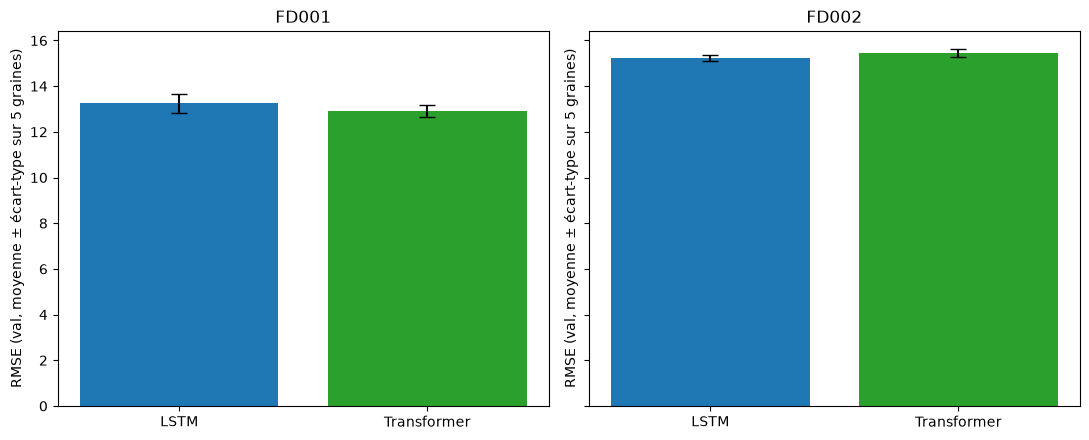

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)

for ax, dataset in zip(axes, ["FD001", "FD002"]):
    models = ["LSTM", "Transformer"]
    means = [all_results[(dataset, m)]["RMSE"].mean() for m in models]
    stds = [all_results[(dataset, m)]["RMSE"].std() for m in models]
    ax.bar(models, means, yerr=stds, capsize=6, color=["tab:blue", "tab:green"])
    ax.set_title(dataset)
    ax.set_ylabel("RMSE (val, moyenne ± écart-type sur 5 graines)")

fig.tight_layout()

**Ce que montre cette figure** : moyenne ± écart-type sur 5 graines, LSTM et Transformer côte
à côte pour chaque volet. Si les barres d'erreur se chevauchent largement, la différence entre
les deux architectures n'est pas visuellement défendable, quel que soit l'écart entre les
moyennes — c'est exactement le point relevé par la relecture externe du projet : un classement
« X devance Y » n'a de sens que si l'écart dépasse ce que le hasard de l'initialisation peut
expliquer à lui seul. Le test t ci-dessus tranche numériquement ce que cette figure suggère
visuellement.